# Runge-Kutta Methods and Stability Regions

For the test equation $\dot y=\lambda y$, a one-step method induces
$$
y_{n+1}=R(z) y_n,\qquad z=h\lambda.
$$
Absolute stability requires $|R(z)|\leq 1$. We compare Euler, RK2, and RK4 stability regions.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/runge-kutta-stability/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/runge-kutta-stability") if Path("python/runge-kutta-stability").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Runge-Kutta Methods and Stability Regions**, with equations and plots designed to expose both the model and the numerical behavior.


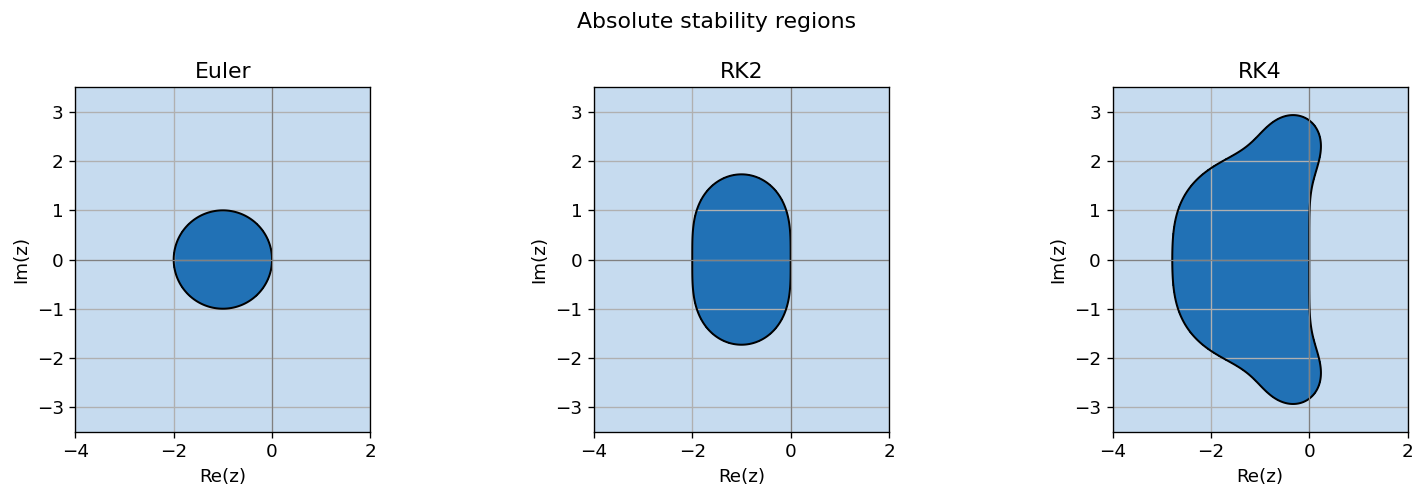

In [2]:
def R_euler(z):
    return 1 + z

def R_rk2(z):
    return 1 + z + 0.5*z**2

def R_rk4(z):
    return 1 + z + z**2/2 + z**3/6 + z**4/24

nx = 350
x = np.linspace(-4, 2, nx)
y = np.linspace(-3.5, 3.5, nx)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

M1 = np.abs(R_euler(Z))
M2 = np.abs(R_rk2(Z))
M4 = np.abs(R_rk4(Z))

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2))
for ax, M, name in zip(axes, [M1, M2, M4], ["Euler", "RK2", "RK4"]):
    ax.contourf(X, Y, M <= 1, levels=[-0.1, 0.5, 1.1], cmap="Blues")
    ax.contour(X, Y, M, levels=[1.0], colors="k", linewidths=1.2)
    ax.axhline(0, color="gray", lw=0.7)
    ax.axvline(0, color="gray", lw=0.7)
    ax.set_title(name)
    ax.set_xlabel("Re(z)")
    ax.set_ylabel("Im(z)")
    ax.set_aspect("equal")

fig.suptitle("Absolute stability regions")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


### References

- E. Hairer, S. P. Nørsett, G. Wanner, *Solving Ordinary Differential Equations I*.
- J. C. Butcher, *Numerical Methods for Ordinary Differential Equations*.
